# Bias correction example

This illustratres use of bias correction functions. We will implement two bias correction approaches currently available in the package:
- simple mean and variance adjustment
- simple quantile-quantile mapping
Bias correction is implemented on the lead-time oriented structure of forecast data. So we will first postprocess the raw forecast to that format. We will subsequently implement bias correction using both approaches and then illustrate how bias is reduced using several plots.

In [2]:
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import cartopy.crs as ccrs
from acacia_s2s_toolkit.postprocess import postprocess_forecast, get_example_data
from acacia_s2s_toolkit.bias_correction import biascorrection_simple_qqmapping, biascorrection_meanvariance

In [3]:
# let's see what the bias corection functions do
print(biascorrection_meanvariance.__doc__)


Apply mean and variance bias correction to forecast and hindcast data.

For each lead time, adjusts the mean and variance of the hindcast and
forecast to match those of the observed data. The correction is computed
from the hindcast/observation pair and then applied to both hindcast and
forecast.

Parameters
----------
forecast : xarray.DataArray
    Forecast data with dimensions (lead_time, member, ...).
hindcast : xarray.DataArray
    Hindcast data with dimensions (lead_time, member, init_date, ...).
observed : xarray.DataArray
    Observed data with dimensions (lead_time, init_date, ...).

Returns
-------
forecast_adjusted : xarray.DataArray
    Bias-corrected forecast, same shape as input forecast.
hindcast_adjusted : xarray.DataArray
    Bias-corrected hindcast, same shape as input hindcast.

Notes
-----
The correction follows:
    adjusted = ((x - mean(x)) * sqrt(var(obs) / var(hindcast))) + mean(obs)

Hindcast variance is computed (separately for each lead time, of course) over

In [5]:
# let's see what the bias corection functions do
print(biascorrection_simple_qqmapping.__doc__)


Apply quantile-quantile mapping bias correction to forecast and hindcast data.

For each lead time, maps the emiprical distribution of the hindcast and forecast
to match the observed empirical distribution using quantile mapping. The transfer
function is derived from the hindcast/observation pair and applied to
both hindcast and forecast. This is simple quantile mapping based on emiprical      
distributions and without extension of tails, and thus by nature bias-corrected forecast 
maxima/minima will not exceed these in observations.   

Parameters
----------
forecast : xarray.DataArray
    Forecast data with dimensions (lead_time, lat, lon, init_date, member).
hindcast : xarray.DataArray
    Hindcast data with dimensions (lead_time, lat, lon, init_date, member).
observed : xarray.DataArray
    Observed data with dimensions (lead_time, lat, lon, init_date).

Returns
-------
forecast_adjusted : xarray.DataArray
    Bias-corrected forecast, same shape as input forecast.
hindcast_adjust

## Getting some data to work with

In [6]:
#this is the data directory - you can change it as it suits you
data_dir="./data"

# this will load example data used in this notebook
# data are available at https://web.csag.uct.ac.za:~wolski/acacia/toolkit/
# comment this line if you want to work with your own data - 
# you will then have to define a file with observational data, and have 
# forecast and hindcast data for given initialization date downloaded to
# the data_dir

get_example_data(data_dir)

file already exists locally ./data/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc
file already exists locally ./data/tp_ECMWF_20260301_madagascar_hc.nc
file already exists locally ./data/tp_ECMWF_20260301_madagascar_fc.nc
file already exists locally ./data/madagascar.geojson


True

## Defining parameters for postprocessing

In [7]:
# defining what you want to process - i.e. forecast date, domain and observed dataset

# nominal forecast date is defined here. 
# This notebook uses example data for this date only
# example data are downloaded by a function get_example_data() called above

nominal_date="2026-03-01"
#target domain
target_domain="madagascar"
#forecast variable
fcst_var="tp"
#foreast model
fcst_model="ECMWF"

#this is file with observational data. It is gridded and covers the period of Jan 1981-March 2026
obs_file=f"{data_dir}/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc"

#we have to provide the name of the variable stored in the obs_file
obs_var="PRCPTOT"

# this is a file with vector data showing the boundaries of the domain - will be used in plotting only
domain_shape_file=f"{data_dir}/madagascar.geojson"

# data will be aggregated into blocks of this size - "5D" is a Pandas expression of temporal base and stands for 5 days
# if you want differently sized blocks - just change it into, say "7D"
agg_window="5D"

#and this defines how data will be aggreagated over the block - in this case it will be a sum of daily values
agg_method="sum"

# this defines regridding parameters for matching the obs and forecast grids. 
# it assumes obs grid is finer, so fine_to_coarse will give forecast grid, coarse_to_fine will give obs grid
# raise_if_missing will stop processing if the spatial overlap between obs and forecast grids of less than fractional 
# threshold
grid_alignment_kwargs=dict(
    direction="fine_to_coarse",
    method="conservative",
    raise_if_missing=True,
    threshold=0.9
)

# this defines time alignment parameter for matching the obs and hindcast time series. 
# raise_if_missing will stop processing if any of the hindcast days are not covered by observations 
time_alignment_kwargs={"raise_if_missing":True}

## Implementing postprocessing

In [20]:
# calling the preprocessing wrapper
hindcast_lt,forecast_lt,obs_lt=postprocess_forecast(
    nominal_date=nominal_date,
    download_dir=data_dir,
    target_domain=target_domain,
    fcst_var=fcst_var,
    fcst_model=fcst_model,
    agg_window=agg_window,
    agg_method=agg_method,
    obs_file=obs_file,
    obs_var=obs_var,
    grid_alignment_kwargs=grid_alignment_kwargs,
    time_alignment_kwargs=time_alignment_kwargs,
    verbose=False
)

logging is False
nominal forecast date: 2026-03-01
download dir: ./data
domain: madagascar
model: ECMWF
forecast variable: tp
aggregation window: 5D
observed file: ./data/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc
observed variable: PRCPTOT
postprocessing done


## Implementing bias correction - 'mean and variance' approach

In [22]:
#applying the mean and variance bias correction
forecast_bc_mv,hindcast_bc_mv=biascorrection_meanvariance(forecast_lt, hindcast_lt, obs_lt)

### Let's evaluate the efficacy of bias correction
For this we will calculate bias in mean in original data, and residual bias in the bias-corrected data.
Bias in mean is considered here to be a difference between the long-term mean of hindcasts, with data pooled across all members and all initiatlization times (but not lead times, as bias is lead-time specific) and long term mean of observations. 


In [24]:
#calculating long term mean in obs
ob_clim=obs_lt.mean("init_date")

# same for hindcast
hc_clim=hindcast_lt.mean(["member", "init_date"])

# same for bias corrected hindcast
hc_clim_bc=hindcast_bc_mv.mean(["member", "init_date"])

#calculating bias as percentage of obs value
bias=((ob_clim-hc_clim)/ob_clim)*100

#residual bias in bias corrected data
resid_bias=((ob_clim-hc_clim_bc)/ob_clim)*100

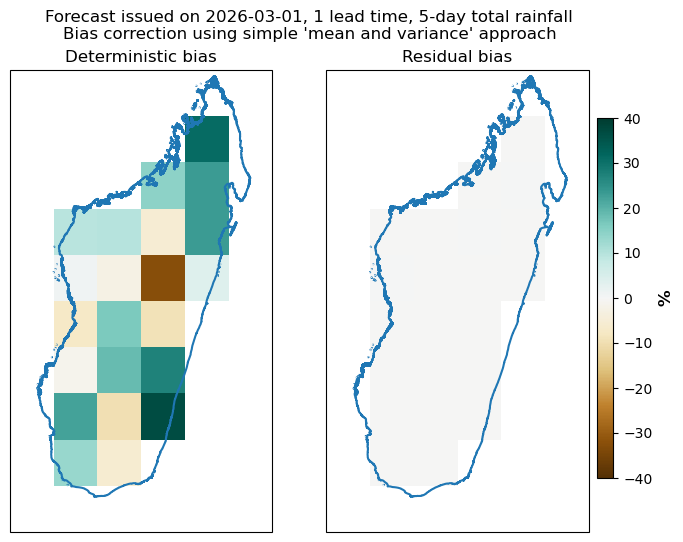

In [25]:
# plotting bias and residual bias

#plotting for a selected lead time
lead_time=1


fig=plt.figure(figsize=(8,6))


# plotting bias in original data
pl=fig.add_subplot(1,2,1, projection=ccrs.PlateCarree())

#plotting
im=bias.sel(lead_time=lead_time).plot(add_colorbar=False, vmin=-40, vmax=40, cmap=plt.cm.BrBG)

#adding overlay
overlay=gpd.read_file(domain_shape_file)
overlay.boundary.plot(ax=pl)

pl.set_title("Deterministic bias")


#plotting residual bias in bias-corrected data

pl=fig.add_subplot(1,2,2, projection=ccrs.PlateCarree())

#plotting
im=resid_bias.sel(lead_time=lead_time).plot(add_colorbar=False, vmin=-40, vmax=40, cmap=plt.cm.BrBG)

#adding colorbar
ax=fig.add_axes([0.86,0.2,0.02,0.6])
cbar = plt.colorbar(im, cax=ax)
cbar.set_label('%', size=12, weight='bold')

#adding overlay
overlay=gpd.read_file(domain_shape_file)
overlay.boundary.plot(ax=pl)

pl.set_title("Residual bias")

plt.subplots_adjust(right=0.85)
plt.suptitle("Forecast issued on {}, {} lead time, {}-day total rainfall\nBias correction using simple 'mean and variance' approach".format(nominal_date, lead_time, agg_window[:-1]))
plt.show()

## Implementing bias correction - simple quantile-quantile mapping approach

In [26]:
#now let's try with the quantile mapping approach
forecast_bc_qq,hindcast_bc_qq=biascorrection_simple_qqmapping(forecast_lt, hindcast_lt, obs_lt)

### Let's evaluate the efficacy of bias correction


In [27]:
# calculating bias in mean in original data, and residual bias in bias-corrected data 

#calculating long term mean in obs and hindcast
ob_clim=obs_lt.mean("init_date")

# same for hindcast
hc_clim=hindcast_lt.mean(["member", "init_date"])

# same for bias corrected hindcast
hc_clim_bc=hindcast_bc_qq.mean(["member", "init_date"])

#calculating bias as percentage of obs value
bias=((ob_clim-hc_clim)/ob_clim)*100

#residual bias in bias corrected data
resid_bias=((ob_clim-hc_clim_bc)/ob_clim)*100

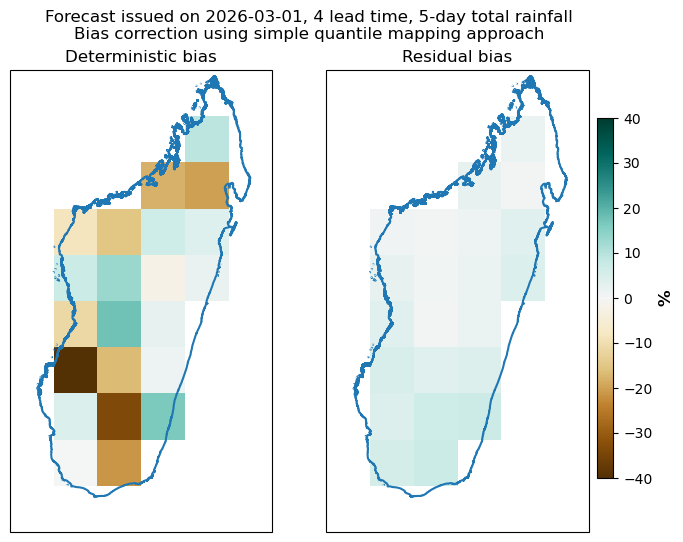

In [28]:
# plotting bias and residual bias

#plotting for a selected lead time
lead_time=4


fig=plt.figure(figsize=(8,6))


# plotting bias in original data
pl=fig.add_subplot(1,2,1, projection=ccrs.PlateCarree())

#plotting
im=bias.sel(lead_time=lead_time).plot(add_colorbar=False, vmin=-40, vmax=40, cmap=plt.cm.BrBG)

#adding overlay
overlay=gpd.read_file(domain_shape_file)
overlay.boundary.plot(ax=pl)

pl.set_title("Deterministic bias")


#plotting residual bias in bias-corrected data

pl=fig.add_subplot(1,2,2, projection=ccrs.PlateCarree())

#plotting
im=resid_bias.sel(lead_time=lead_time).plot(add_colorbar=False, vmin=-40, vmax=40, cmap=plt.cm.BrBG)

#adding colorbar
ax=fig.add_axes([0.86,0.2,0.02,0.6])
cbar = plt.colorbar(im, cax=ax)
cbar.set_label('%', size=12, weight='bold')

#adding overlay
overlay=gpd.read_file(domain_shape_file)
overlay.boundary.plot(ax=pl)

pl.set_title("Residual bias")

plt.subplots_adjust(right=0.85)
plt.suptitle("Forecast issued on {}, {} lead time, {}-day total rainfall\nBias correction using simple quantile mapping approach".format(nominal_date, lead_time, agg_window[:-1]))
plt.show()

As the above figures show, the 'mean and variance' approach produces basically no residual bias. Which is expected, as the procedure makes sure that the mean of hindcasts is exactly the same as mean of observations. 

Quantile mapping, however, produces a small residual bias, but one has to consider that there is a difference between mean and median, and the qq bias correction adjusts for median of the distribution rathe than for mean, while the biascorrection_meanvariance function adjusts mean explicitly. 

## Comparing distributions
We can illustrate the effects of bias correction and differences between the two methods using distributions

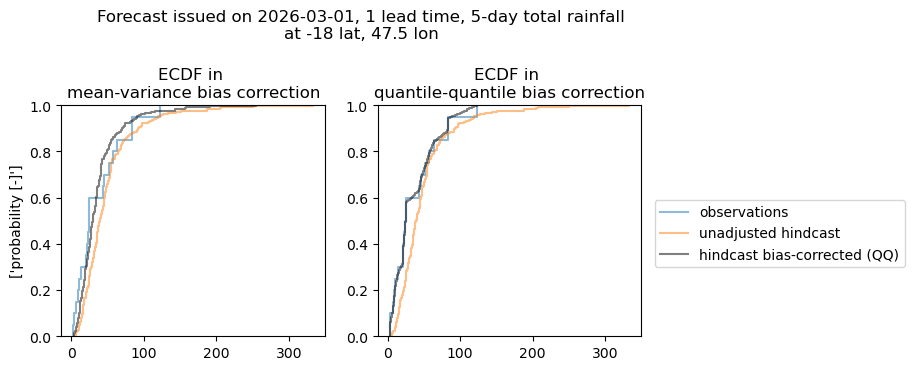

In [30]:
# plotting distributions in original and bias-corrected data

#selecting lead time
lead_time=1

#selecting a location
lat,lon=-18,47.5

fig=plt.figure(figsize=(8,3))

# plotting distribution in original data and in data corrected with mean and variance approach
pl=fig.add_subplot(1,2,1)

# extracting data for the selected location and lead time
ob=obs_lt.isel(lead_time=lead_time).sel(lat=lat,lon=lon, method="nearest")
hc=hindcast_lt.isel(lead_time=lead_time).sel(lat=lat,lon=lon, method="nearest")
hc_bc_mv=hindcast_bc_mv.isel(lead_time=lead_time).sel(lat=lat,lon=lon, method="nearest")

#plotting cumulative distribution functions - empirical ones, of course
pl.ecdf(ob.data, alpha=0.5, label="observations")
pl.ecdf(hc.data.flatten(), alpha=0.5, label="unadjusted hindcast")
pl.ecdf(hc_bc_mv.data.flatten(), alpha=0.5, label="hindcast bias-corrected (MV)", color="black")

#adding some labels
pl.set_title("ECDF in \nmean-variance bias correction")
pl.set_ylabel(["probability [-]"])



#plotting distribution in original data and in data corrected using simple quantile mapping approach

pl=fig.add_subplot(1,2,2)

#extracting data for the selected location and leadtime
hc_bc_qq=hindcast_bc_qq.isel(lead_time=lead_time).sel(lat=lat,lon=lon, method="nearest")

#plotting ecdfs
pl.ecdf(ob.data, alpha=0.5, label="observations")
pl.ecdf(hc.data.flatten(), alpha=0.5, label="unadjusted hindcast")
pl.ecdf(hc_bc_qq.data.flatten(), alpha=0.5, label="hindcast bias-corrected (QQ)", color="black")

#adding labels
pl.set_title("ECDF in \nquantile-quantile bias correction")

#finishing off
plt.suptitle("Forecast issued on {}, {} lead time, {}-day total rainfall\nat {} lat, {} lon".format(nominal_date, lead_time, agg_window[:-1], lat,lon), y=1.2)
plt.legend(loc=(1.05, 0.3))
plt.subplots_adjust(right=0.85)
plt.show()




## Illustrating effects of bias correction in time series of hindcast and forecast data
The effect of bias correction can also be shown in the time series of forecasts. This has to be done for a particular location and lead time.

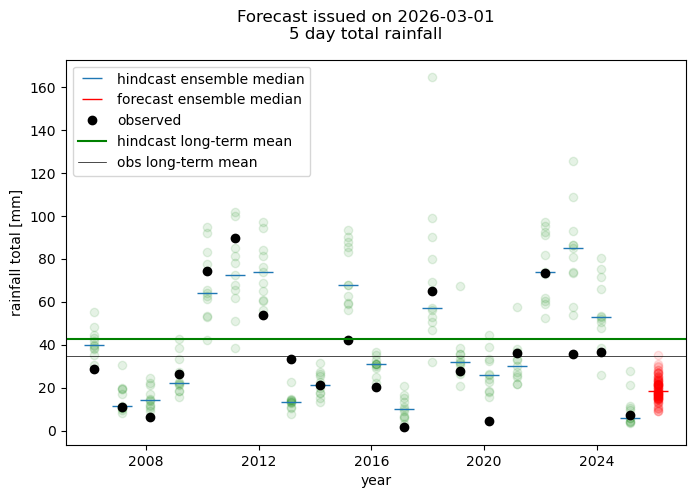

In [31]:
#Let's plot original, unadjusted hindcast and forecast first

# here we will use a location
lat,lon=-19,47.5

#we will plot it for a selected lead time
lead_time=0

# we use unadjusted forecast
hcst=hindcast_lt.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")
fcst=forecast_lt.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")

#and observations in the lead-time oriented format
obs=obs_lt.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")


#now plotting
fig=plt.figure(figsize=(8,5))

pl=fig.add_subplot(1,1,1)

#plotting hincasts - individual members
for m in hcst.member:
    pl.plot(hcst.init_date,hcst.sel(member=m), "o", color="green", alpha=0.1)

#and hindcast median
pl.plot(hcst.init_date, hcst.median("member"), "_", ms=15, label="hindcast ensemble median")

#plotting forecast - individual members
for m in fcst.member:
    cont=True
    pl.plot(fcst.init_date,fcst.sel(member=m), "o", color="red",alpha=0.1)

# and forecast median
pl.plot(fcst.init_date,fcst.median("member"), "_", color="red", ms=15, label="forecast ensemble median")

#plotting observations
pl.plot(obs.init_date,obs, "o", color="black", label="observed")

#we can add long term mean - for hindcast
pl.axhline(hcst.mean("member").mean(), label="hindcast long-term mean", color="green")

#and for observations
pl.axhline(obs.mean(), label="obs long-term mean", color="black", lw=0.5)

#finishing off
plt.suptitle("Forecast issued on {}\n{} day total rainfall".format(nominal_date, agg_window[:-1]))
pl.set_xlabel("year")
pl.set_ylabel("rainfall total [mm]")
plt.legend()
plt.show()

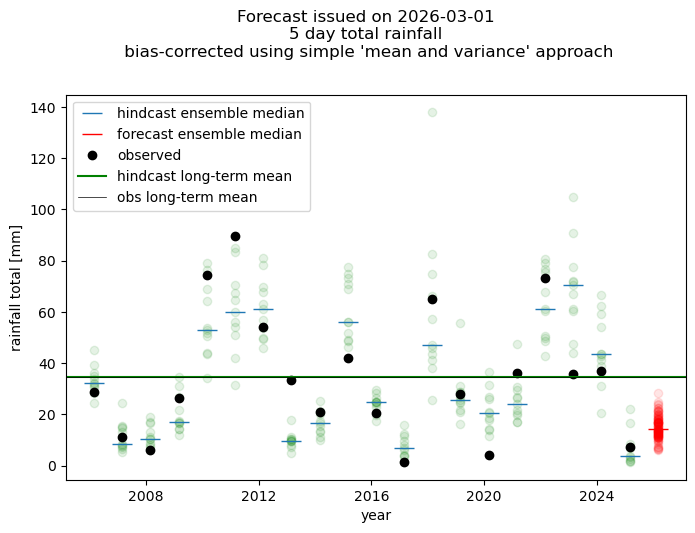

In [32]:
# now the same thing for bias-corrected hindcast and forecast

# we use bias corrected forecast
hcst=hindcast_bc_mv.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")
fcst=forecast_bc_mv.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")

#and observations in the lead-time oriented format
obs=obs_lt.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")


#now plotting
fig=plt.figure(figsize=(8,5))

pl=fig.add_subplot(1,1,1)

#plotting hincasts - individual members
for m in hcst.member:
    pl.plot(hcst.init_date,hcst.sel(member=m), "o", color="green", alpha=0.1)

#and hindcast median
pl.plot(hcst.init_date, hcst.median("member"), "_", ms=15, label="hindcast ensemble median")


#plotting forecast - individual members
for m in fcst.member:
    cont=True
    pl.plot(fcst.init_date,fcst.sel(member=m), "o", color="red",alpha=0.1)

pl.plot(fcst.init_date,fcst.median("member"), "_", color="red", ms=15, label="forecast ensemble median")

#plotting observations
pl.plot(obs.init_date,obs, "o", color="black", label="observed")

#we can add long term median
pl.axhline(hcst.mean("member").mean(), label="hindcast long-term mean", color="green")
pl.axhline(obs.mean(), label="obs long-term mean", color="black", lw=0.5)


plt.suptitle("Forecast issued on {}\n{} day total rainfall\n bias-corrected using simple 'mean and variance' approach".format(nominal_date, agg_window[:-1]), y=1.05)

pl.set_xlabel("year")
pl.set_ylabel("rainfall total [mm]")
plt.legend()
plt.show()

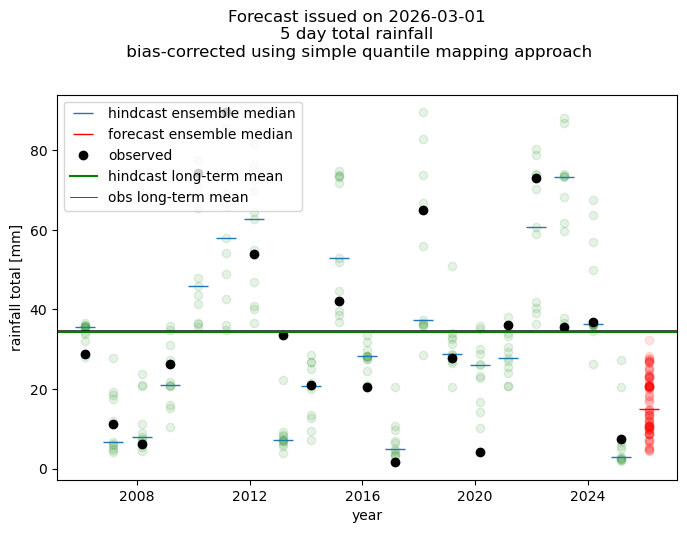

In [33]:
# now the same thing for bias-corrected hindcast and forecast - simple quantile mapping approach

# we use bias corrected forecast
hcst=hindcast_bc_qq.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")
fcst=forecast_bc_qq.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")

#and observations in the lead-time oriented format
obs=obs_lt.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")


#now plotting
fig=plt.figure(figsize=(8,5))

pl=fig.add_subplot(1,1,1)

#plotting hincasts - individual members
for m in hcst.member:
    pl.plot(hcst.init_date,hcst.sel(member=m), "o", color="green", alpha=0.1)

#and hindcast median
pl.plot(hcst.init_date, hcst.median("member"), "_", ms=15, label="hindcast ensemble median")


#plotting forecast - individual members
for m in fcst.member:
    cont=True
    pl.plot(fcst.init_date,fcst.sel(member=m), "o", color="red",alpha=0.1)

pl.plot(fcst.init_date,fcst.median("member"), "_", color="red", ms=15, label="forecast ensemble median")

#plotting observations
pl.plot(obs.init_date,obs, "o", color="black", label="observed")

#we can add long term median
pl.axhline(hcst.mean("member").mean(), label="hindcast long-term mean", color="green")
pl.axhline(obs.mean(), label="obs long-term mean", color="black", lw=0.5)


plt.suptitle("Forecast issued on {}\n{} day total rainfall\n bias-corrected using simple quantile mapping approach".format(nominal_date, agg_window[:-1]), y=1.05)

pl.set_xlabel("year")
pl.set_ylabel("rainfall total [mm]")
plt.legend()
plt.show()